### Итоговый отчет
1) Лучший по pr_auc : LGBM with optuma
2) Лучший по вторичному признаку roc_auc : XGBoost
3) Дисбаланс нии на одном алгоритме не наблюдался
4) Алгоритмы бустинга лучшие, но куда более дорогие по времени и памяти. Например, LGBM-оптимизация заняла примерно 12 (!) часов. А накладные расходы периодически сбрасывали вычислинеия, поскольку требовали размещения в памяти единовременного нефрагментированного участка 200-300М (при параллельном запуске память как раз часто была фрагментирована)
5) Строго говоря, для эффективного использования optuna нужен лпыт и понимание, какие гиперпараметры для алгоритма нужно оптимизировать. Также существенно влияет датасет (размер, нормальность, количество классов, метрика)

In [29]:
import pickle

from matplotlib import pyplot as plt

from public.classification_utils import (
    DEC_TR,
    EXTRA,
    LGBM,
    LOG_REG,
    RAN_FOR,
    XGB,
    ClassificationResult,
    report,
)

ALGORITHMS = [LOG_REG, RAN_FOR, DEC_TR, EXTRA, XGB, LGBM]

stats = []
for item in ALGORITHMS:
    with open(f"./data/pick/{item}.pkl", "rb") as file:
        stats.append(pickle.load(file))
stats_tuned = []
for item in ALGORITHMS:
    with open(f"./data/pick/{item}_tuned.pkl", "rb") as file:
        stats_tuned.append(pickle.load(file))

def draw(stats: list[ClassificationResult], stats_tuned: list[ClassificationResult], feature_name: str, y_min: float = 0.6) -> None:
    series = sorted(
        [{"title" : item.title, feature_name: getattr(item, feature_name)} for item in stats], 
        key=lambda x: x[feature_name]
    )
    series_tuned = sorted(
        [{"title" : item.title, feature_name: getattr(item, feature_name)} for item in stats_tuned], 
        key=lambda x: x[feature_name]
    )
    # best_series = series if series[-1][feature_name] > series_tuned[-1][feature_name] else series_tuned
    is_default_better = series[-1][feature_name] > series_tuned[-1][feature_name]
    best_series = series if is_default_better else series_tuned

    if is_default_better:
        x = [d["title"] for d in series]
        y = [d[feature_name] for d in series]
        y_tuned = []
        for item in x:       
            y_tuned.append(
                next((i[feature_name] for i in series_tuned if i['title'] == f'{item}_tuned'), None)
            )
    else:    
        x = [d["title"] for d in series_tuned]
        y = []
        for item in x:       
            y.append(
                next((i[feature_name] for i in series if i['title'] == item[:-6]), None)
            )
        y_tuned = [d[feature_name] for d in series_tuned]
        

    plt.figure(figsize=(14, 10))
    plt.title(feature_name.upper())
    stats_line = plt.plot(x, y, marker='o')
    stats_tuned_line = plt.plot(x, y_tuned, marker='o')
    for i, val in enumerate(y):
        plt.text(i, val + 0.005, f"{val:.4f}", color=stats_line[0].get_color())
    for i, val in enumerate(y_tuned):
        plt.text(i, val - 0.005, f"{val:.4f}", color=stats_tuned_line[0].get_color())

    plt.legend(("default", "optuna"))
    plt.xticks(rotation=45) 
    plt.grid(True)
    plt.ylim(y_min, 1.05)
    plt.show()

In [30]:
for i, item in enumerate(stats):
    print(f"{i+1}.{item.title} : {item.pr_auc} : {item.roc_auc}")
print('-'*70)
for i, item in enumerate(stats_tuned):
    print(f"{i+1}.{item.title} : {item.pr_auc} : {item.roc_auc}")

1.logistic_regression : 0.9639489883109011 : 0.9933916543314254
2.random_forest : 0.9929221454605524 : 0.9989446302720699
3.decision_tree : 0.7757954221400802 : 0.9293089609545249
4.extra_trees : 0.9940393685389133 : 0.9991628680276896
5.extreme_gradient_boosting : 0.9966386420015247 : 0.9995139069363951
6.light_gradient_boosting_machine : 0.9963686913530966 : 0.9994495762694282
----------------------------------------------------------------------
1.logistic_regression_tuned : 0.9639177992045855 : 0.9933917060357917
2.random_forest_tuned : 0.983012829765132 : 0.9972257118563869
3.decision_tree_tuned : 0.9064126100316097 : 0.971346339984535
4.extra_trees_tuned : 0.9914678034534014 : 0.9987102534783674
5.extreme_gradient_boosting_tuned : 0.9960292482371609 : 0.9994239628248192
6.light_gradient_boosting_machine_tuned : 0.996779173100143 : 0.999491479685442


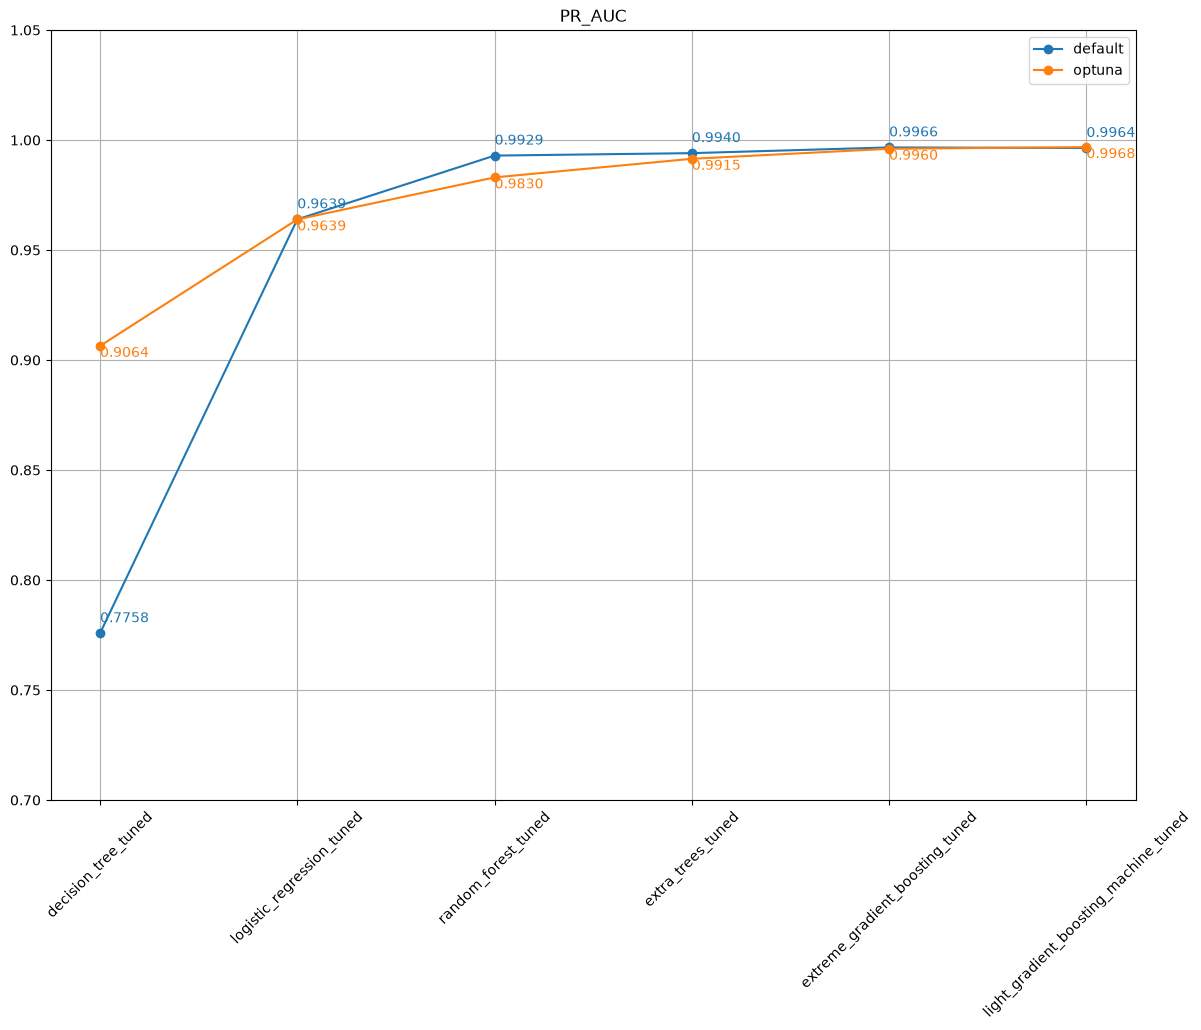

In [31]:
draw(stats, stats_tuned, "pr_auc", 0.7)

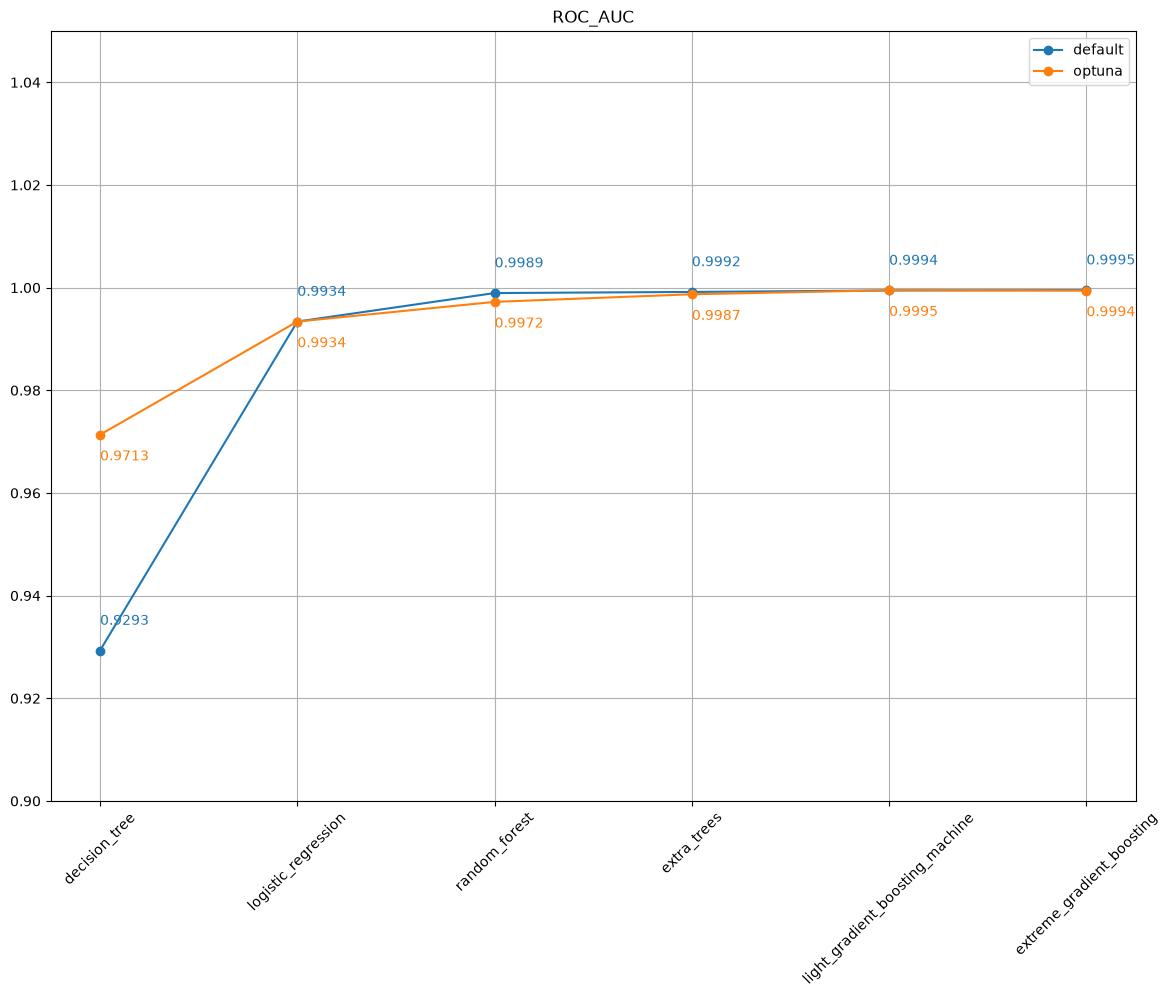

In [32]:
draw(stats, stats_tuned, "roc_auc", 0.9)


	light_gradient_boosting_machine_tuned


pr_auc,roc_auc,accuracy
0.996779,0.999491,0.977714


,precision,recall,f1-score,support
0,0.980,0.991,0.986,1381.000
1,0.989,0.985,0.987,1575.000
2,0.976,0.974,0.975,1398.000
3,0.980,0.978,0.979,1428.000
4,0.978,0.971,0.974,1365.000
5,0.985,0.971,0.978,1263.000
6,0.981,0.984,0.983,1375.000
7,0.975,0.979,0.977,1459.000
8,0.966,0.979,0.973,1365.000
9,0.968,0.963,0.965,1391.000


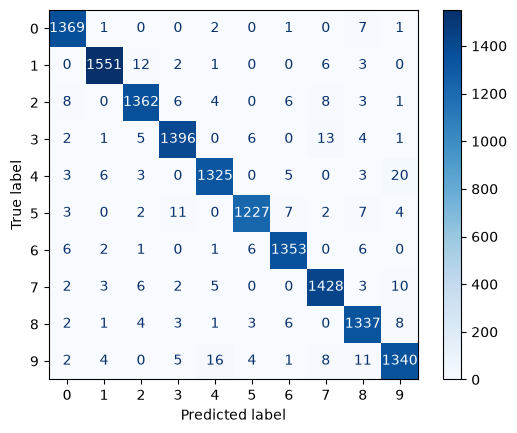

In [33]:
max_stats = max(stats, key=lambda p: p.pr_auc)
max_stats_tuned = max(stats_tuned, key=lambda p: p.pr_auc)

report(max_stats if max_stats.pr_auc > max_stats_tuned.pr_auc else max_stats_tuned, matrix=True)
